In [1]:
import numpy as np #para manejar arreglos
from matplotlib import pyplot as plt #para graficar

from numpy.fft import fft, fftfreq
# https://numpy.org/doc/stable/reference/routines.fft.html
# fft calcula la transformada
# fftfreq calcula las (posibles) frecuencias involucradas

from scipy.io import wavfile #leer archivos de audio wav

from scipy.integrate import solve_ivp
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html

plt.rcParams["figure.figsize"] = (10,5) #tamaño de los gráficos: ancho x alto

# Aplicación de Fourier: identificación de frecuencias.

## Predador-Presa:
$$
\begin{cases}
x_1'&= -0.5x_1+0.02x_1x_2\\
x_2' &= x_2-0.02x_1x_2\\
x_1(0)&=4 \\
x_2(0) &= 20
\end{cases}
$$

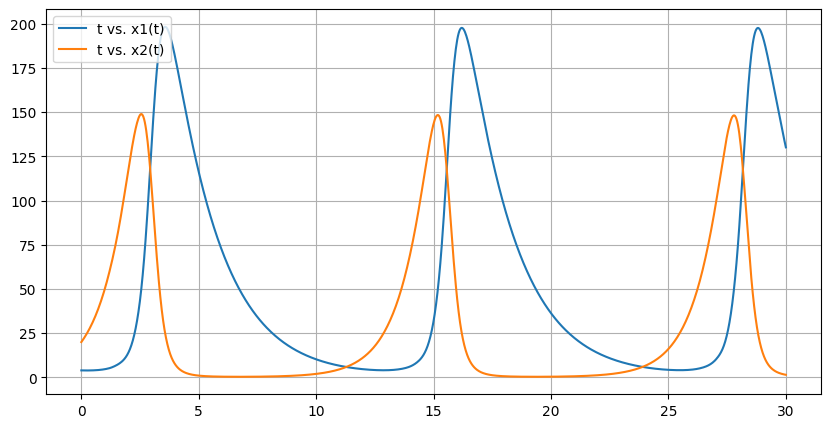

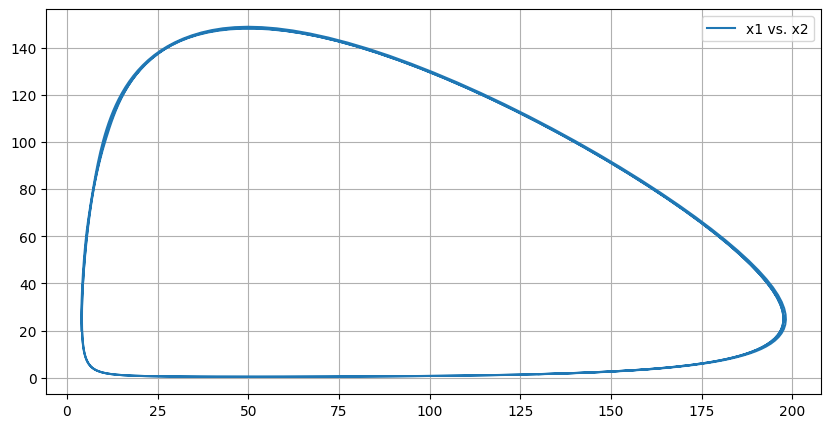

In [14]:
def func(t,z): #ojo z es un vector: así lo necesita solve_ivp
    x1 = z[0]
    x2 = z[1]
    f1 = -0.5*x1 + 0.02*x1*x2
    f2 = x2 - 0.02*x1*x2
    f = [f1,f2] #así lo necesita solve_ivp
    return f


# intervalo de tiempo: experimentar cambiando!
t0 = 0
tf = 30 # 50. Con 50 justo se pega periódica en los borces y por eso da mejor.

# condiciones iniciales: experimentar cambiando!
x1_0 = 4
x2_0 = 20
z0 = [x1_0, x2_0] #así lo necesita solve_ivp

# resuelvo el sistema por solve_ivp
solucion = solve_ivp(func, [t0, tf], z0, dense_output=True)

cantidad_tiempos = 1000
vals_t = np.linspace(t0,tf,cantidad_tiempos)  # para que evalúe la solución en muchos puntos
vals_sol = solucion.sol(vals_t)

# grafico t vs. x(t)
plt.plot(vals_t, vals_sol[0], label="t vs. x1(t)") #el [0] es para que devuelva solamente valores de x1

# grafico t vs. y(t)
plt.plot(vals_t, vals_sol[1], label="t vs. x2(t)") #el [1] es para que devuelva solamente valores de x2
plt.legend()
plt.grid() #marcas horizontales y verticales de refencia
plt.show() #muestra los gráficos hasta el momento


# grafico retrato fase (o diagrama de fases): x vs y
plt.plot(vals_sol[0], vals_sol[1], label="x1 vs. x2")
plt.legend()
plt.grid() #marcas horizontales y verticales de refencia

In [15]:
coefs_fourier_x = fft(vals_sol[0])

freq_muestreo = cantidad_tiempos/(tf - t0)
cantidad_muestras = cantidad_tiempos
paso_temporal = 1/freq_muestreo
frecuencias = fftfreq(cantidad_muestras, d=paso_temporal)

[ 0.          0.06666667  0.1         0.16666667  0.23333333 -0.23333333
 -0.16666667 -0.1        -0.06666667]


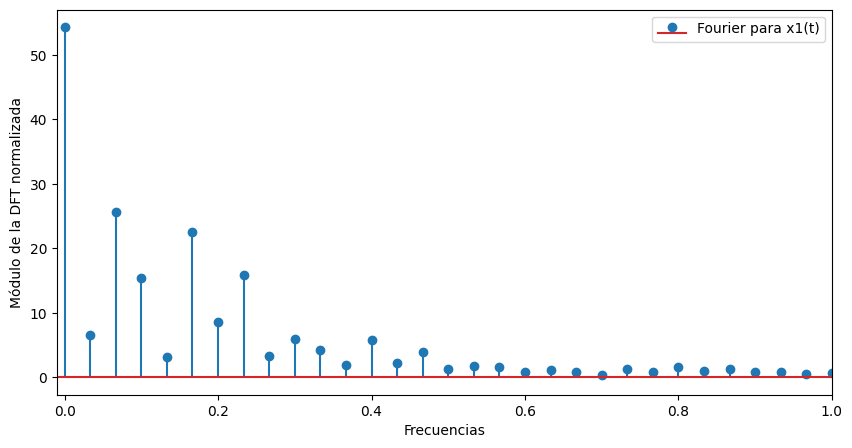

In [16]:
plt.stem(frecuencias, abs(coefs_fourier_x)/cantidad_muestras, label="Fourier para x1(t)" )
plt.legend()
plt.xlabel('Frecuencias')
plt.ylabel('Módulo de la DFT normalizada')

plt.xlim(-0.01, 1)

print(frecuencias[abs(coefs_fourier_x)/cantidad_muestras > 10])

---
# Aplicación de Fourier: identificación de frecuencias.

## Audio.

(0.0, 10000.0)

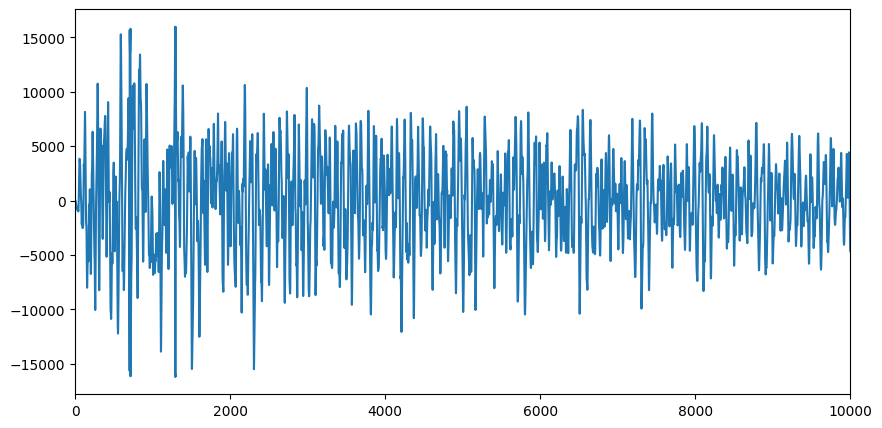

In [19]:
[freq_muestreo, datos] = wavfile.read('la_mayor_mono.wav', 'r')

plt.plot(datos)
plt.xlim(0,10000)

In [20]:
coefs_fourier = fft(datos)

cantidad_muestras = len(datos)
paso_temporal = 1/freq_muestreo
frecuencias = fftfreq(cantidad_muestras, d=paso_temporal)

(0.0, 800.0)

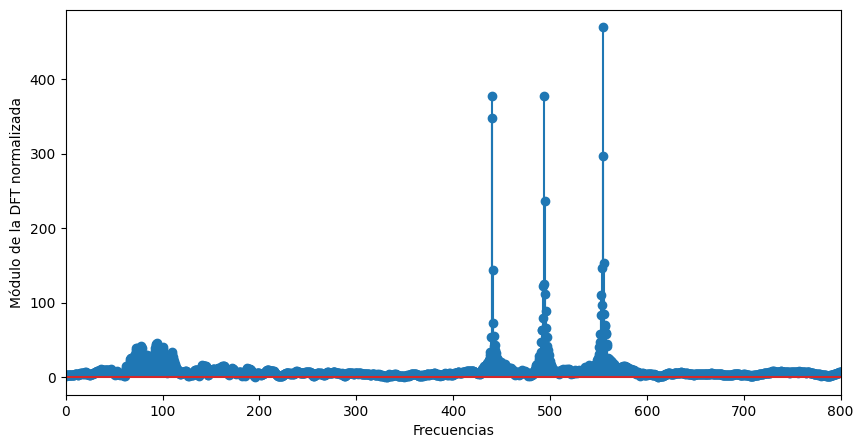

In [21]:
plt.stem(frecuencias, abs(coefs_fourier)/cantidad_muestras )
plt.xlabel('Frecuencias')
plt.ylabel('Módulo de la DFT normalizada')
plt.xlim(0,800)

In [22]:
# imprimo las frecuencias con valor abs fourier mayor a algo
print(frecuencias[abs(coefs_fourier)/cantidad_muestras > 300])

[ 440.   440.5  494.   554.5 -554.5 -494.  -440.5 -440. ]


---
## Aplicación que mediante transformada de Fourier en tiempo real, identifica la especie de pájaro a partir de su canto:
### https://ebird.org/species/whimon1

---
---
# Aplicación de Fourier: filtros digitales

In [23]:
[freq_muestreo, datos] = wavfile.read('la_mayor_mono.wav', 'r')

coefs_fourier = fft(datos)

cantidad_muestras = len(datos)
paso_temporal = 1/freq_muestreo
frecuencias = fftfreq(cantidad_muestras, d=paso_temporal)

(0.0, 800.0)

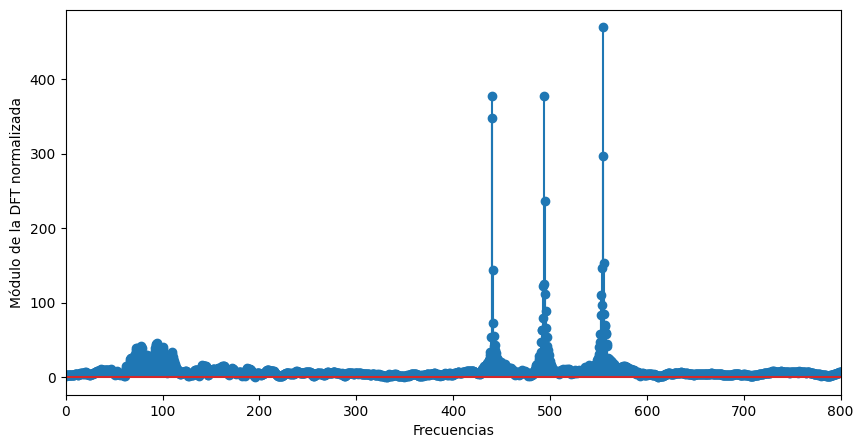

In [24]:
plt.stem(frecuencias, abs(coefs_fourier)/cantidad_muestras )
plt.xlabel('Frecuencias')
plt.ylabel('Módulo de la DFT normalizada')
plt.xlim(0,800)

## Quiero eliminar esas frecuencias (ruido) alrededor de 100: digamos entre 50 y 150, por ejemplo.

In [25]:
filtro = np.ones_like(frecuencias) #vector de todos 1 de tamaño igual a frecuencias

# posiciones de las frecuencias inicial y final, de las que quiero eliminar
pos_freq_50 = np.where(frecuencias==50)[0][0]
pos_freq_150 = np.where(frecuencias==150)[0][0]

# pongo 0 en las frecuencias que quiero eliminar: de 50 a 150
filtro[pos_freq_50:pos_freq_150] = 0

# multiplico lugar a lugar: donde el filtro tiene 1 queda igual, donde tiene 0 se hace 0.
coefs_fourier_filtrados = coefs_fourier*filtro

(0.0, 800.0)

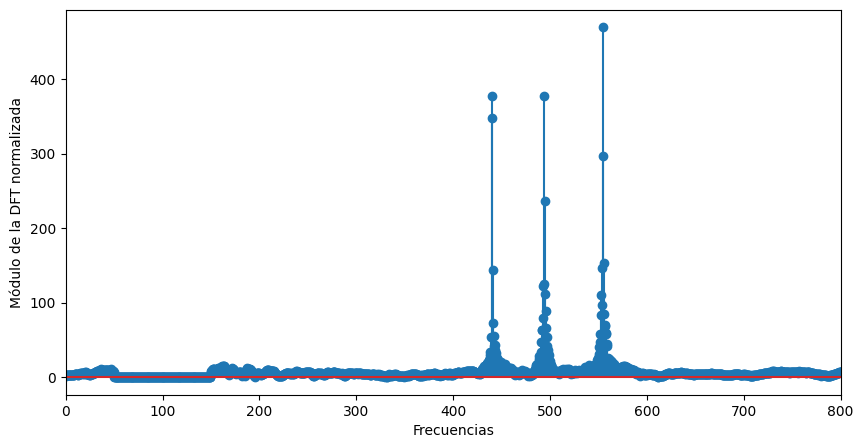

In [26]:
plt.stem(frecuencias, abs(coefs_fourier_filtrados)/cantidad_muestras )
plt.xlabel('Frecuencias')
plt.ylabel('Módulo de la DFT normalizada')
plt.xlim(0,800)

---
---
# **Ejercicios:** 1 y 6 de la guía.
# **Ejercicios:** 7, 8 y 9 de la guía.